In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from pypfopt import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

In [57]:

assets = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'GLD', 'BTC-USD']

data = yf.download(
    assets,
    start='2018-01-01',
    end='2025-01-01'
)['Close']

print(data.head())


[*********************100%***********************]  6 of 6 completed

Ticker           AAPL       AMZN       BTC-USD         GLD      GOOGL  \
Date                                                                    
2018-01-01        NaN        NaN  13657.200195         NaN        NaN   
2018-01-02  40.304173  59.450500  14982.099609  125.150002  53.220634   
2018-01-03  40.297165  60.209999  15201.000000  124.820000  54.128628   
2018-01-04  40.484333  60.479500  15599.200195  125.459999  54.338890   
2018-01-05  40.945267  61.457001  17429.500000  125.330002  55.059429   

Ticker           MSFT  
Date                   
2018-01-01        NaN  
2018-01-02  78.870377  
2018-01-03  79.237396  
2018-01-04  79.934814  
2018-01-05  80.925842  


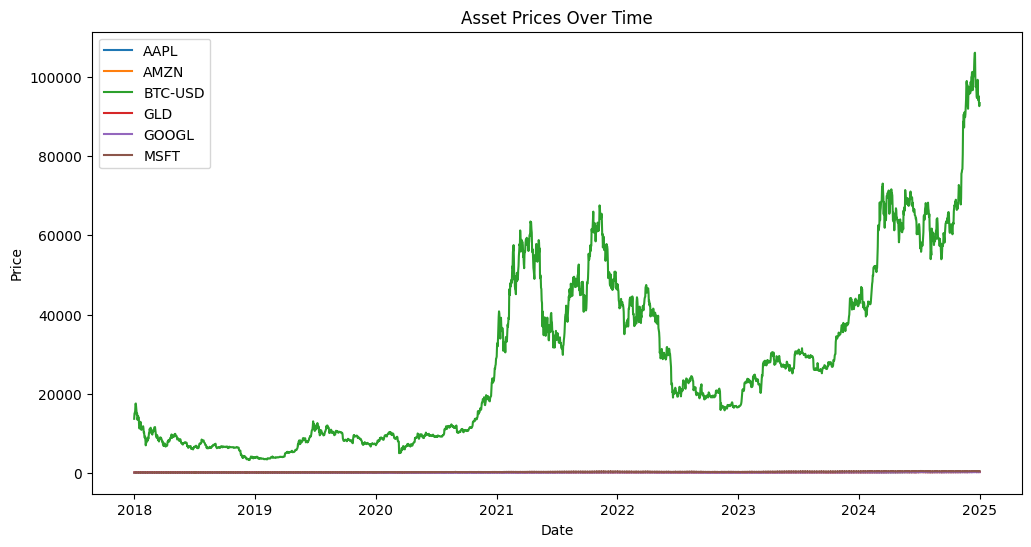

In [58]:
plt.figure(figsize=(12,6))

for stock in data.columns:
    plt.plot(data[stock], label=stock)

plt.title("Asset Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [59]:
data = data.select_dtypes(include=['number'])

returns = data.pct_change().dropna()

In [60]:
print(data.dtypes)

Ticker
AAPL       float64
AMZN       float64
BTC-USD    float64
GLD        float64
GOOGL      float64
MSFT       float64
dtype: object


Mean Returns
Ticker
AAPL       0.001208
AMZN       0.000878
BTC-USD    0.001561
GLD        0.000530
GOOGL      0.001065
MSFT       0.001329
dtype: float64

Covariance Matrix
Ticker       AAPL      AMZN   BTC-USD       GLD     GOOGL      MSFT
Ticker                                                             
AAPL     0.000352  0.000241  0.000178  0.000015  0.000226  0.000241
AMZN     0.000241  0.000479  0.000194  0.000019  0.000274  0.000271
BTC-USD  0.000178  0.000194  0.001421  0.000045  0.000180  0.000191
GLD      0.000015  0.000019  0.000045  0.000081  0.000018  0.000014
GOOGL    0.000226  0.000274  0.000180  0.000018  0.000377  0.000254
MSFT     0.000241  0.000271  0.000191  0.000014  0.000254  0.000320


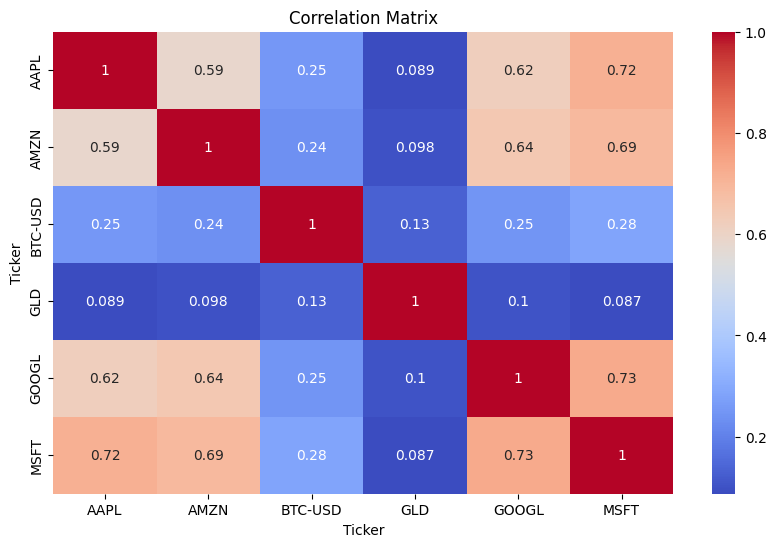

In [61]:
mean_returns = returns.mean()
cov_matrix = returns.cov()

print("Mean Returns")
print(mean_returns)

print("\nCovariance Matrix")
print(cov_matrix)

# Correlation Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    returns.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

XGBoost Model Trained Successfully
Mean Squared Error: 9.511033277884451e-05
R2 Score: 0.1781140903012881


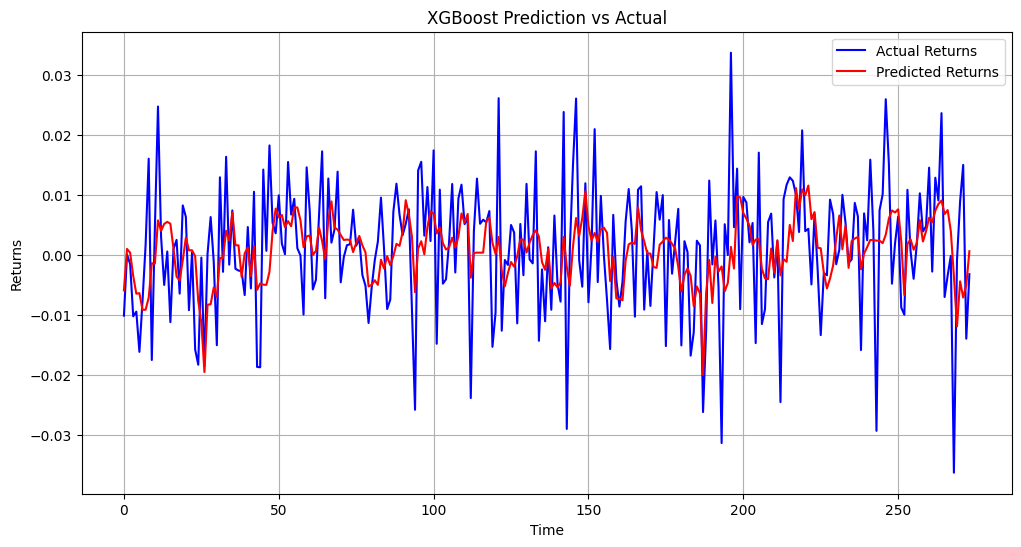


Predicted Return Used For Optimization:
Ticker
AAPL       0.000828
AMZN       0.000828
BTC-USD    0.000828
GLD        0.000828
GOOGL      0.000828
MSFT       0.000828
dtype: float32


In [62]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =========================================================
# FEATURE ENGINEERING
# =========================================================

# Create market return
returns['Market_Return'] = returns.mean(axis=1)

# Moving averages
returns['MA_5'] = returns['Market_Return'].rolling(5).mean()
returns['MA_10'] = returns['Market_Return'].rolling(10).mean()

# Volatility
returns['Volatility'] = returns['Market_Return'].rolling(10).std()

# Remove NaN values
returns = returns.dropna()

# =========================================================
# FEATURES & TARGET
# =========================================================

X = returns[['MA_5', 'MA_10', 'Volatility']]
y = returns['Market_Return']

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

# =========================================================
# XGBOOST MODEL
# =========================================================

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# =========================================================
# PREDICTIONS
# =========================================================

predictions = model.predict(X_test)

# =========================================================
# EVALUATION
# =========================================================

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("XGBoost Model Trained Successfully")
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# =========================================================
# ACTUAL VS PREDICTED GRAPH
# =========================================================

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Actual Returns',
    color='blue'
)

plt.plot(
    predictions,
    label='Predicted Returns',
    color='red'
)

plt.title("XGBoost Prediction vs Actual")
plt.xlabel("Time")
plt.ylabel("Returns")

plt.legend()
plt.grid(True)

plt.show()

# =========================================================
# USE PREDICTED RETURNS FOR OPTIMIZATION
# =========================================================

predicted_return = np.mean(predictions)

mu = pd.Series(
    [predicted_return] * len(data.columns),
    index=data.columns
)

print("\nPredicted Return Used For Optimization:")
print(mu)

In [63]:
# =========================================================
# RETURN MODEL SELECTION
# =========================================================

# Historical Returns
historical_mu = expected_returns.mean_historical_return(data)

# XGBoost Predicted Returns
predicted_return = np.mean(predictions)

xgb_mu = pd.Series(
    [predicted_return] * len(data.columns),
    index=data.columns
)

# Model Selection
model_choice = "Historical"   # or "XGBoost" or "Hybrid"
if model_choice == "Historical":
    mu = historical_mu

elif model_choice == "XGBoost":
    mu = xgb_mu

else:
    mu = (historical_mu + xgb_mu) / 2

c:\Users\hp\OneDrive\Desktop\My projects\Portfolio\venv\Lib\site-packages\pypfopt\expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(


In [64]:
S = risk_models.sample_cov(data)

In [65]:
ef = EfficientFrontier(mu, S)

In [66]:
weights = ef.max_sharpe()

cleaned_weights = ef.clean_weights()

print("\nOptimal Portfolio Allocation:")
print(cleaned_weights)



Optimal Portfolio Allocation:
OrderedDict({'AAPL': 0.07895, 'AMZN': 0.0, 'BTC-USD': 0.0, 'GLD': 0.5749, 'GOOGL': 0.0, 'MSFT': 0.34615})


In [67]:
performance = ef.portfolio_performance(verbose=True)

Expected annual return: 21.7%
Annual volatility: 14.9%
Sharpe Ratio: 1.46


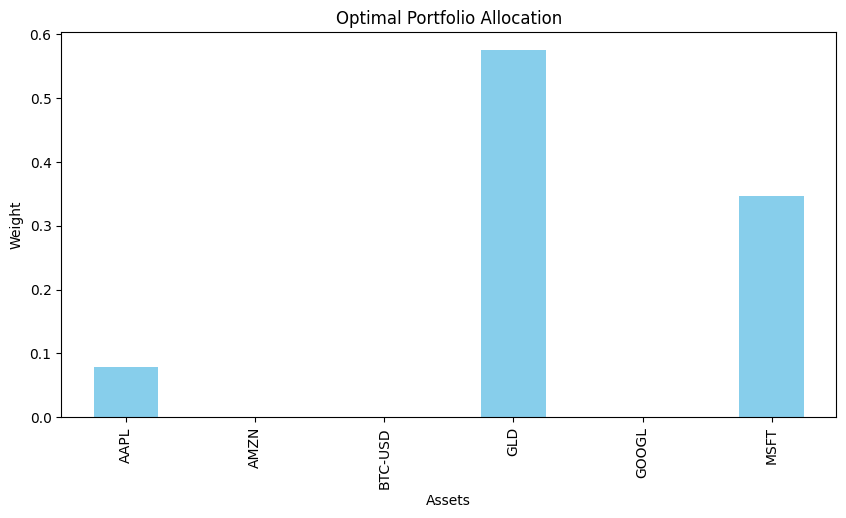

In [68]:
weights_df = pd.Series(cleaned_weights)

plt.figure(figsize=(10,5))

weights_df.plot(
    kind='bar',
    color='skyblue'
)

plt.title("Optimal Portfolio Allocation")
plt.xlabel("Assets")
plt.ylabel("Weight")

plt.show()

In [69]:
def suggest_portfolio(risk_level):

    if risk_level == "Conservative":
        return {
            "Bonds/Gold": "60%",
            "Stocks": "30%",
            "Crypto": "10%"
        }

    elif risk_level == "Moderate":
        return {
            "Stocks": "50%",
            "Gold": "30%",
            "Crypto": "20%"
        }

    elif risk_level == "Aggressive":
        return {
            "Stocks": "70%",
            "Crypto": "20%",
            "Gold": "10%"
        }

risk = "Moderate"

print("\nSuggested Portfolio:")
print(suggest_portfolio(risk))



Suggested Portfolio:
{'Stocks': '50%', 'Gold': '30%', 'Crypto': '20%'}


In [70]:
num_portfolios = 5000

results = np.zeros((3, num_portfolios))

for i in range(num_portfolios):

    weights = np.random.random(len(mean_returns))
    weights /= np.sum(weights)

    portfolio_return = np.sum(mean_returns * weights) * 252

    portfolio_stddev = np.sqrt(
        np.dot(weights.T,
               np.dot(cov_matrix * 252, weights))
    )

    sharpe_ratio = portfolio_return / portfolio_stddev

    results[0,i] = portfolio_return
    results[1,i] = portfolio_stddev
    results[2,i] = sharpe_ratio

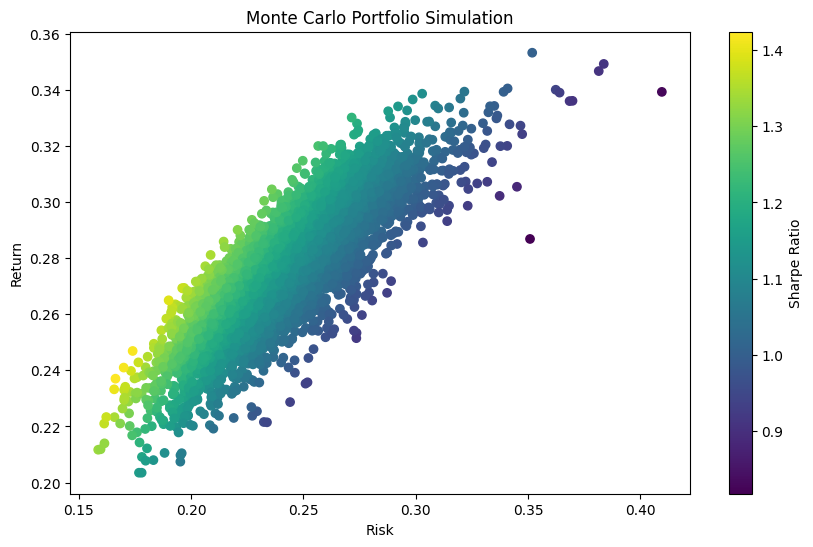

In [71]:
plt.figure(figsize=(10,6))

plt.scatter(
    results[1,:],
    results[0,:],
    c=results[2,:],
    cmap='viridis'
)

plt.colorbar(label='Sharpe Ratio')

plt.xlabel('Risk')
plt.ylabel('Return')

plt.title('Monte Carlo Portfolio Simulation')

plt.show()

In [72]:
print("\nPROJECT COMPLETED SUCCESSFULLY")
print("Features Included:")
print("1. Data Collection")
print("2. Risk Analysis")
print("3. ML Prediction")
print("4. Portfolio Optimization")
print("5. Risk Profiling")
print("6. Monte Carlo Simulation")


PROJECT COMPLETED SUCCESSFULLY
Features Included:
1. Data Collection
2. Risk Analysis
3. ML Prediction
4. Portfolio Optimization
5. Risk Profiling
6. Monte Carlo Simulation


In [73]:
data.shape

(2557, 6)